In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.naive_bayes import GaussianNB

In [3]:
# 1. LOAD DATA

# Membaca data dengan pemisah titik koma (;) sesuai format file asli
try:
 df = pd.read_csv('prediksi kelulusan mhs.csv', sep=';')
 print("✓ Berhasil memuat data training dan testing.")
except FileNotFoundError:
 print("Error: Pastikan file CSV berada di folder yang sama dengan script ini.")

✓ Berhasil memuat data training dan testing.


In [4]:
df.head()

,ID_Mahasiswa,Gender,IPS_Sem1,IPS_Sem2,IPS_Sem3,IPS_Sem4,Total_SKS_Ambil,Total_SKS_Lulus,Nilai_Matkul_Killer,Jml_Mengulang,Status_Beasiswa,Bekerja,Label_Lulus
0,MHS001,0,2.724.882.755.418.020,32.577.165.362.252.000,32.369.304.168.724.100,36.842.250.616.328.700,144,134,4,4,1,1,1
1,MHS002,1,27.586.906.017.759.900,3.082.082.409.920.360,3.116.547.619.529.870,305.899.730.617.175,71,44,1,0,1,1,1
2,MHS003,1,2.0,33.017.206.125.190.600,28.744.780.159.571.100,2.918.066.441.752.610,131,113,4,3,1,0,1
3,MHS004,0,32.085.055.548.315.800,34.162.309.285.605.700,2.853.300.426.820.660,29.850.807.153.201.200,129,116,2,1,0,1,1
4,MHS005,0,26.254.617.382.783.200,2.610.808.996.454.550,3.474.421.428.859.500,3.790.425.293.019.510,77,63,3,5,0,1,1


**Preprocessing Data**

In [5]:
def fix_ips_format(val):
    # 1. Pastikan data adalah string dan hapus semua titik
    clean_val = str(val).replace('.', '')

    # 2. Jika datanya kosong, kembalikan 0.0
    if not clean_val or clean_val == 'nan':
        return 0.0

    # 3. Ambil karakter pertama sebagai angka depan (integer)
    # Sisanya dijadikan desimal
    fixed_val = clean_val[0] + '.' + clean_val[1:]

    # 4. Ubah kembali ke tipe float
    return float(fixed_val)

# Terapkan fungsi ini ke semua kolom IPS
kolom_ips = ['IPS_Sem1', 'IPS_Sem2', 'IPS_Sem3', 'IPS_Sem4']

for col in kolom_ips:
    df[col] = df[col].apply(fix_ips_format)

# Opsional: Bulatkan jadi 2 angka di belakang koma agar rapi
df[kolom_ips] = df[kolom_ips].round(2)

print("Data setelah dibersihkan:")
print(df[kolom_ips].head())

Data setelah dibersihkan:
   IPS_Sem1  IPS_Sem2  IPS_Sem3  IPS_Sem4
0      2.72      3.26      3.24      3.68
1      2.76      3.08      3.12      3.06
2      2.00      3.30      2.87      2.92
3      3.21      3.42      2.85      2.99
4      2.63      2.61      3.47      3.79


In [6]:
# Menghitung Efisiensi SKS
df['SKS_Efficiency'] = df['Total_SKS_Lulus'] / df['Total_SKS_Ambil']

# Menghitung Tren IPS (Selisih semester terbaru dengan semester awal)
df['Tren_IPS'] = df['IPS_Sem4'] - df['IPS_Sem1']

In [7]:
# 3. SELEKSI FITUR
# Fitur: Semua kolom kecuali ID dan Label Target
# Sesuaikan list ini dengan nama kolom di datasetmu
features = ['Gender', 'IPS_Sem1', 'IPS_Sem2', 'IPS_Sem3', 'IPS_Sem4',
            'Total_SKS_Ambil', 'Total_SKS_Lulus', 'Nilai_Matkul_Killer',
            'Jml_Mengulang', 'Status_Beasiswa', 'Bekerja', 'Tren_IPS', 'SKS_Efficiency']

X = df[features]
y = df['Label_Lulus'] # Target: 0 (Tepat) atau 1 (Telat)

C:\Users\nicco ganteng\AppData\Local\Temp\ipykernel_23128\1211654374.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Label_Lulus', palette='rocket')


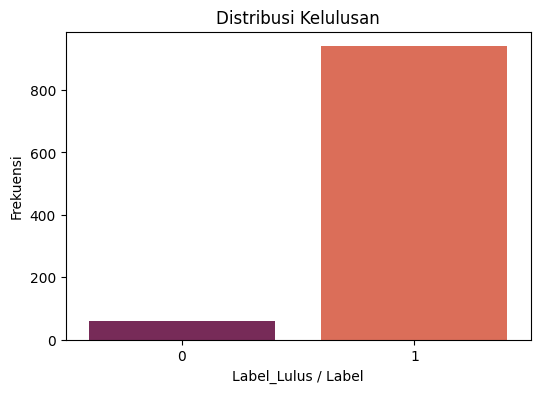

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Label_Lulus', palette='rocket')

plt.title('Distribusi Kelulusan')
plt.xlabel('Label_Lulus / Label')
plt.ylabel('Frekuensi')
plt.show()

In [9]:
print(list(X.columns))

['Gender', 'IPS_Sem1', 'IPS_Sem2', 'IPS_Sem3', 'IPS_Sem4', 'Total_SKS_Ambil', 'Total_SKS_Lulus', 'Nilai_Matkul_Killer', 'Jml_Mengulang', 'Status_Beasiswa', 'Bekerja', 'Tren_IPS', 'SKS_Efficiency']


In [10]:
#membagi data training dan testing
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
#Menerapkan SMOTE untuk menyeimbangkan data

from imblearn.over_sampling import SMOTE
from collections import Counter

# 2. Inisialisasi SMOTE
# k_neighbors=5 adalah standar (mencari 5 tetangga terdekat)
smote = SMOTE(random_state=42)

# 3. Terapkan SMOTE hanya pada data Training
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

# Cek perbandingan data sekarang
print(f"Jumlah data sebelum SMOTE: {Counter(y_train)}")
print(f"Jumlah data setelah SMOTE: {Counter(y_train_balanced)}")

Jumlah data sebelum SMOTE: Counter({1: 757, 0: 43})
Jumlah data setelah SMOTE: Counter({1: 757, 0: 757})


In [13]:
#Training Model
# --- Model 1: Decision Tree ---
# Latih ulang Decision Tree dengan data seimbang
dt_model_balanced = DecisionTreeClassifier(criterion='entropy', max_depth=5)
dt_model_balanced.fit(X_train_balanced, y_train_balanced)

# Latih ulang Naive Bayes dengan data seimbang
nb_model_balanced = GaussianNB()
nb_model_balanced.fit(X_train_balanced, y_train_balanced)

print("Model telah dilatih ulang menggunakan data hasil SMOTE!")

Model telah dilatih ulang menggunakan data hasil SMOTE!


--- Laporan Klasifikasi Setelah SMOTE ---
              precision    recall  f1-score   support

           0       0.88      0.88      0.88        17
           1       0.99      0.99      0.99       183

    accuracy                           0.98       200
   macro avg       0.94      0.94      0.94       200
weighted avg       0.98      0.98      0.98       200



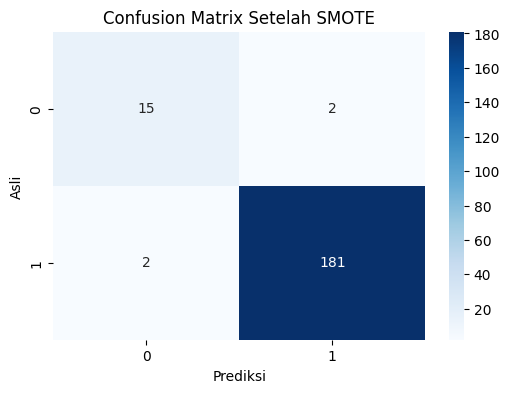

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Prediksi menggunakan model Decision Tree yang baru
y_pred_new = dt_model_balanced.predict(X_test)

print("--- Laporan Klasifikasi Setelah SMOTE ---")
print(classification_report(y_test, y_pred_new))

# Visualisasi Confusion Matrix Baru
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_new), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix Setelah SMOTE')
plt.xlabel('Prediksi')
plt.ylabel('Asli')
plt.show()

In [15]:
import joblib

# Simpan model Decision Tree yang sudah dilatih dengan data seimbang tadi
# 'dt_model_balanced' adalah nama variabel model kamu sebelumnya
joblib.dump(dt_model_balanced, 'model_lulus.pkl')

print("Berhasil! File model_lulus.pkl sudah tercipta di folder Colab.")

Berhasil! File model_lulus.pkl sudah tercipta di folder Colab.


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# 1. Load Model & Data
@st.cache_resource
def load_assets():
    model = joblib.load('model_lulus.pkl')
    # Pastikan file CSV menggunakan separator yang benar
    df = pd.read_csv('prediksi kelulusan mhs.csv', sep=';')
    return model, df

model, df = load_assets()

st.set_page_config(page_title="Prediksi Kelulusan", layout="wide")
st.title("🎓 Dashboard Prediksi Kelulusan Mahasiswa")

menu = st.sidebar.selectbox("Pilih Menu", ["Statistik Data", "Cek Prediksi"])

if menu == "Cek Prediksi":
    st.subheader("🔍 Analisis Data Kelulusan Mahasiswa")

    # 1. RESTUKTURISASI TAMPILAN: Membagi halaman menjadi 2 tab
    tab1, tab2 = st.tabs(["📋 Prediksi Individu (Form)", "📁 Prediksi Massal (Upload CSV Angkatan 2023)"])

    # =========================================================================
    # TAB 1: PREDIKSI INDIVIDU (FORM)
    # =========================================================================
    with tab1:
        st.write("Silakan masukkan data mahasiswa satu per satu.")
        
        # --- TEMPEL KODE FORM LAMA DI SINI ---
        with st.form("form_prediksi"):
            col1, col2, col3 = st.columns(3)

            with col1:
                gender = st.selectbox("Gender", ["Laki-laki", "Perempuan"])
                ips1 = st.number_input("IPS Semester 1", 0.0, 4.0, 3.0)
                ips2 = st.number_input("IPS Semester 2", 0.0, 4.0, 3.0)
                ips3 = st.number_input("IPS Semester 3", 0.0, 4.0, 3.0)
                ips4 = st.number_input("IPS Semester 4", 0.0, 4.0, 3.0)

            with col2:
                sks_ambil = st.number_input("Total SKS Diambil", 0, 160, 80)
                sks_lulus = st.number_input("Total SKS Lulus", 0, 160, 75)
                matkul_killer = st.number_input("Nilai Matkul Killer (Skala 0-100)", 0, 100, 70)
                jml_mengulang = st.number_input("Jumlah Mata Kuliah Mengulang", 0, 20, 0)

            with col3:
                beasiswa = st.selectbox("Status Beasiswa", ["Tidak Ada", "Ada"])
                bekerja = st.selectbox("Status Bekerja", ["Tidak", "Ya"])

            btn = st.form_submit_button("Analisis Kelulusan")

            if btn:
                # --- PRE-PROCESSING INPUT ---
                gender_val = 1 if gender == "Laki-laki" else 0
                beasiswa_val = 1 if beasiswa == "Ada" else 0
                bekerja_val = 1 if bekerja == "Ya" else 0

                tren_ips = ips4 - ips1
                sks_efficiency = sks_lulus / sks_ambil if sks_ambil > 0 else 0

                input_data = [[
                    gender_val, ips1, ips2, ips3, ips4,
                    sks_ambil, sks_lulus, matkul_killer, jml_mengulang,
                    beasiswa_val, bekerja_val, tren_ips, sks_efficiency
                ]]

                hasil = model.predict(input_data)

                st.divider()
                if hasil[0] == 0:
                    st.success("🎯 Hasil Prediksi: **LULUS TEPAT WAKTU**")
                    st.balloons()
                else:
                    st.error("⚠️ Hasil Prediksi: **BERPOTENSI TERLAMBAT**")

    # =========================================================================
    # TAB 2: PREDIKSI MASSAL (UPLOAD CSV ANGKATAN 2023)
    # =========================================================================
    with tab2:
        st.write("Silakan unggah dataset berformat CSV untuk memprediksi banyak mahasiswa sekaligus.")
        
        # Komponen upload file CSV
        uploaded_file = st.file_uploader("Upload File CSV", type=["csv"])

        if uploaded_file is not None:
            # Membaca data yang diunggah
            try:
                df_massal = pd.read_csv(uploaded_file, sep=None, engine='python')
            except Exception as e:
                st.error(f"Gagal membaca file CSV: {e}")
                st.stop()

            # Validasi Kolom Wajib (berdasarkan format data training asli)
            wajib_cols = [
                'Gender', 'IPS_Sem1', 'IPS_Sem2', 'IPS_Sem3', 'IPS_Sem4',
                'Total_SKS_Ambil', 'Total_SKS_Lulus', 'Nilai_Matkul_Killer',
                'Jml_Mengulang', 'Status_Beasiswa', 'Bekerja'
            ]
            
            missing_cols = [col for col in wajib_cols if col not in df_massal.columns]

            if missing_cols:
                st.error(f"❌ Gagal memproses! Kolom berikut tidak ditemukan di dalam file CSV: **{', '.join(missing_cols)}**")
            else:
                st.success("✅ File valid! Memproses prediksi massal...")

                # Filtering dataset sesuai kolom input mentah
                X_massal_raw = df_massal[wajib_cols].copy()
                
                # --- PRE-PROCESSING: BEBERSIH DATA FORMAT IPS TIPE STRING ---
                def fix_ips_format(val):
                    clean_val = str(val).replace('.', '')
                    if not clean_val or clean_val.lower() == 'nan':
                        return 0.0
                    if len(clean_val) > 1:
                        return float(clean_val[0] + '.' + clean_val[1:])
                    return float(clean_val)

                kolom_ips = ['IPS_Sem1', 'IPS_Sem2', 'IPS_Sem3', 'IPS_Sem4']
                for col_ips in kolom_ips:
                    X_massal_raw[col_ips] = X_massal_raw[col_ips].apply(fix_ips_format)

                # --- PRE-PROCESSING: MAPPING KATEGORI STRING KE NUMERIK ---
                # Jika data CSV berisi teks "Laki-laki" / "Perempuan", "Ada" / "Tidak", ubah ke angka 1 atau 0
                mapping_gender = {'Laki-laki': 1, 'Perempuan': 0, 'Laki-Laki': 1}
                mapping_umum = {'Ada': 1, 'Tidak Ada': 0, 'Ya': 1, 'Tidak': 0}
                
                if X_massal_raw['Gender'].dtype == object:
                    X_massal_raw['Gender'] = X_massal_raw['Gender'].replace(mapping_gender)
                    
                if X_massal_raw['Status_Beasiswa'].dtype == object:
                    X_massal_raw['Status_Beasiswa'] = X_massal_raw['Status_Beasiswa'].replace(mapping_umum)
                    
                if X_massal_raw['Bekerja'].dtype == object:
                    X_massal_raw['Bekerja'] = X_massal_raw['Bekerja'].replace(mapping_umum)
                    
                # Pastikan di-cast ke bentuk numerik setelah direplace
                X_massal_raw['Gender'] = pd.to_numeric(X_massal_raw['Gender'], errors='coerce')
                X_massal_raw['Status_Beasiswa'] = pd.to_numeric(X_massal_raw['Status_Beasiswa'], errors='coerce')
                X_massal_raw['Bekerja'] = pd.to_numeric(X_massal_raw['Bekerja'], errors='coerce')

                # Menghitung Fitur Turunan (sesuai data training)
                X_massal_raw['SKS_Efficiency'] = X_massal_raw.apply(
                    lambda row: row['Total_SKS_Lulus'] / row['Total_SKS_Ambil'] if row['Total_SKS_Ambil'] > 0 else 0, axis=1
                )
                X_massal_raw['Tren_IPS'] = X_massal_raw['IPS_Sem4'] - X_massal_raw['IPS_Sem1']

                # Susun dataset sesuai urutan baku 13 fitur model
                fitur_model = [
                    'Gender', 'IPS_Sem1', 'IPS_Sem2', 'IPS_Sem3', 'IPS_Sem4',
                    'Total_SKS_Ambil', 'Total_SKS_Lulus', 'Nilai_Matkul_Killer',
                    'Jml_Mengulang', 'Status_Beasiswa', 'Bekerja', 'Tren_IPS', 'SKS_Efficiency'
                ]
                X_massal = X_massal_raw[fitur_model]
                
                # Imputasi sederhana jika ada data kosong (handling NaN)
                X_massal = X_massal.fillna(0)

                # Jalankan prediksi massal menggunakan model AI
                try:
                    prediksi_hasil = model.predict(X_massal)
                    
                    # Buat salinan DataFrame untuk hasil
                    df_hasil = df_massal.copy()

                    # Mapping prediksi 0 -> Tepat Waktu, 1 -> Terlambat (Sesuaikan konsistensi label)
                    mapping_label = {0: 'Tepat Waktu', 1: 'Terlambat'}
                    df_hasil['Status Prediksi'] = [mapping_label.get(p, 'Terlambat') for p in prediksi_hasil]

                    # Menampilkan Tabel Hasil
                    st.write("### 📄 Tabel Hasil Prediksi Data Mahasiswa")
                    st.dataframe(df_hasil)

                    # --- VISUALISASI DISTRIBUSI (DI BAWAH TABEL MASSAL) ---
                    st.write("### 📊 Statistik Prediksi Kelulusan Angkatan 2023")
                    
                    import matplotlib.pyplot as plt
                    
                    # Hitung rekap jumlah Tepat Waktu vs Terlambat
                    rekap_status = df_hasil['Status Prediksi'].value_counts().reset_index()
                    rekap_status.columns = ['Status', 'Jumlah']
                    
                    # Atur warna sesuai instruksi (Hijau untuk Tepat Waktu, Merah untuk Terlambat)
                    warna_custom = {'Tepat Waktu': '#2ecc71', 'Terlambat': '#e74c3c'}
                    warna_grafik = [warna_custom[stats] for stats in rekap_status['Status']]

                    col_chart1, col_chart2 = st.columns(2)

                    with col_chart1:
                        # Grafik 1: Pie Chart
                        fig_pie, ax_pie = plt.subplots(figsize=(4, 4))
                        ax_pie.pie(rekap_status['Jumlah'], labels=rekap_status['Status'], 
                                   autopct='%1.1f%%', startangle=140, colors=warna_grafik, explode=[0.05]*len(rekap_status))
                        ax_pie.set_title("Persentase Distribusi")
                        st.pyplot(fig_pie)

                    with col_chart2:
                        # Grafik 2: Bar Chart
                        fig_bar, ax_bar = plt.subplots(figsize=(6, 4))
                        bar_plot = ax_bar.bar(rekap_status['Status'], rekap_status['Jumlah'], color=warna_grafik)
                        ax_bar.set_title("Jumlah Riil Mahasiswa")
                        ax_bar.set_ylabel("Total Mahasiswa")
                        # Menambahkan label angka di atas batang
                        for bar in bar_plot:
                            yval = bar.get_height()
                            ax_bar.text(bar.get_x() + bar.get_width()/2, yval + 0.5, int(yval), ha='center', va='bottom', fontweight='bold')
                        st.pyplot(fig_bar)

                    # --- FITUR DOWNLOAD ---
                    st.write("---")
                    csv_download = df_hasil.to_csv(index=False, sep=';').encode('utf-8')
                    st.download_button(
                        label="⬇️ Download File Hasil Prediksi (.CSV)",
                        data=csv_download,
                        file_name="Hasil_Prediksi_Massal_Angkatan_2023.csv",
                        mime="text/csv",
                    )

                except ValueError as e:
                    st.error(f"⚠️ Model AI mengalami error saat prediksi. Pastikan tipe data pada CSV sesuai. Error code: {e}")

elif menu == "Statistik Data":
    st.write("Silakan masukkan kode visualisasi data kamu di sini.")

Overwriting app.py


In [ ]:
# # 1. Dapatkan IP Address (Password untuk Tunnel)
# import urllib
# ip = urllib.request.urlopen('https://ident.me').read().decode('utf8')
# print("Salin Password Ini:", ip)

# # 2. Matikan proses yang masih tersisa
# !pkill streamlit

# # 3. Instal localtunnel (Supaya tidak tanya "Ok to proceed?")
# !npm install -g localtunnel

# # 4. Jalankan Streamlit & Localtunnel
# # Tunggu sampai muncul tulisan "your url is: ..."
# !streamlit run app.py & lt --port 8501

Salin Password Ini: 180.254.161.144


'pkill' is not recognized as an internal or external command,
operable program or batch file.



added 22 packages in 24s

3 packages are looking for funding
  run `npm fund` for details
^C
